In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

ROOT      = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED = os.path.join(ROOT, 'data', 'processed')

print("Paths set ✓")
print("Processed folder:", PROCESSED)

Paths set ✓
Processed folder: C:\Users\aniru\OneDrive\Desktop\Retail Seg\data\processed


In [2]:
uci  = pd.read_parquet(os.path.join(PROCESSED, 'uci_clean.parquet'))
hm   = pd.read_parquet(os.path.join(PROCESSED, 'hm_clean.parquet'))
inst = pd.read_parquet(os.path.join(PROCESSED, 'inst_clean.parquet'))

for name, df in [('UCI', uci), ('H&M', hm), ('Instacart', inst)]:
    print(f"{name:12} — {len(df):>12,} rows | {df['customer_id'].nunique():>10,} customers")

UCI          —      779,425 rows |      5,878 customers
H&M          —   28,813,419 rows |  1,362,281 customers
Instacart    —   32,434,489 rows |    206,209 customers


In [3]:
def compute_rfm(df, snapshot_date=None):
    """
    Compute RFM table from a standardised transaction dataframe.
    
    Parameters
    ----------
    df            : cleaned dataframe with customer_id, invoice_date, order_id, revenue
    snapshot_date : the 'today' date for recency calculation.
                    Defaults to 1 day after the last transaction.
    Returns
    -------
    rfm : dataframe with one row per customer and R, F, M raw values + scores
    """
    df = df.copy()
    df['invoice_date'] = pd.to_datetime(df['invoice_date'])

    if snapshot_date is None:
        snapshot_date = df['invoice_date'].max() + pd.Timedelta(days=1)

    print(f"Snapshot date: {snapshot_date.date()}")

    # ── Raw RFM values ─────────────────────────────────
    rfm = df.groupby('customer_id').agg(
        recency   = ('invoice_date', lambda x: (snapshot_date - x.max()).days),
        frequency = ('order_id',     'nunique'),
        monetary  = ('revenue',      'sum')
    ).reset_index()

    # ── Score each metric 1–5 using quintiles ──────────
    # Recency: lower days = better = higher score (so we reverse it)
    rfm['r_score'] = pd.qcut(rfm['recency'],   q=5, labels=[5,4,3,2,1]).astype(int)
    rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'),
                              q=5, labels=[1,2,3,4,5]).astype(int)
    rfm['m_score'] = pd.qcut(rfm['monetary'].rank(method='first'),
                              q=5, labels=[1,2,3,4,5]).astype(int)

    # ── Combined RFM score (simple sum, range 3–15) ────
    rfm['rfm_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

    # ── Segment label ──────────────────────────────────
    rfm['segment'] = rfm.apply(assign_segment, axis=1)

    return rfm

In [4]:
def assign_segment(row):
    r = row['r_score']
    f = row['f_score']
    m = row['m_score']
    score = row['rfm_score']

    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r >= 3 and f >= 2 and m <= 2:
        return 'Potential Loyalists'
    elif r <= 2 and f >= 4 and m >= 4:
        return 'At-Risk High Value'
    elif r <= 2 and f >= 3:
        return 'At-Risk'
    elif r == 1 and f == 1:
        return 'Lost'
    elif m >= 4 and f <= 2:
        return 'Big Spenders'
    else:
        return 'Occasional'

In [5]:
print("=" * 40)
print("UCI Online Retail")
print("=" * 40)
rfm_uci = compute_rfm(uci)
print(rfm_uci.shape)
print(rfm_uci['segment'].value_counts())

UCI Online Retail
Snapshot date: 2011-12-10
(5878, 9)
segment
Champions              1297
Occasional             1195
Loyal Customers        1138
At-Risk                 601
Lost                    513
New Customers           443
Potential Loyalists     386
At-Risk High Value      223
Big Spenders             82
Name: count, dtype: int64


In [6]:
print("=" * 40)
print("H&M Fashion")
print("=" * 40)
rfm_hm = compute_rfm(hm)
print(rfm_hm.shape)
print(rfm_hm['segment'].value_counts())

H&M Fashion
Snapshot date: 2020-09-23
(1362281, 9)
segment
Champions              337486
Occasional             292519
Loyal Customers        239320
At-Risk                140168
Lost                   116945
Potential Loyalists     93179
New Customers           83424
At-Risk High Value      47095
Big Spenders            12145
Name: count, dtype: int64


In [7]:
print("=" * 40)
print("Instacart Grocery")
print("=" * 40)
rfm_inst = compute_rfm(inst)
print(rfm_inst.shape)
print(rfm_inst['segment'].value_counts())

Instacart Grocery
Snapshot date: 2023-01-02
(206209, 9)
segment
Champions              58222
Occasional             43481
Loyal Customers        37111
Lost                   27028
Potential Loyalists    23164
At-Risk                11601
Big Spenders            3050
At-Risk High Value      2259
New Customers            293
Name: count, dtype: int64


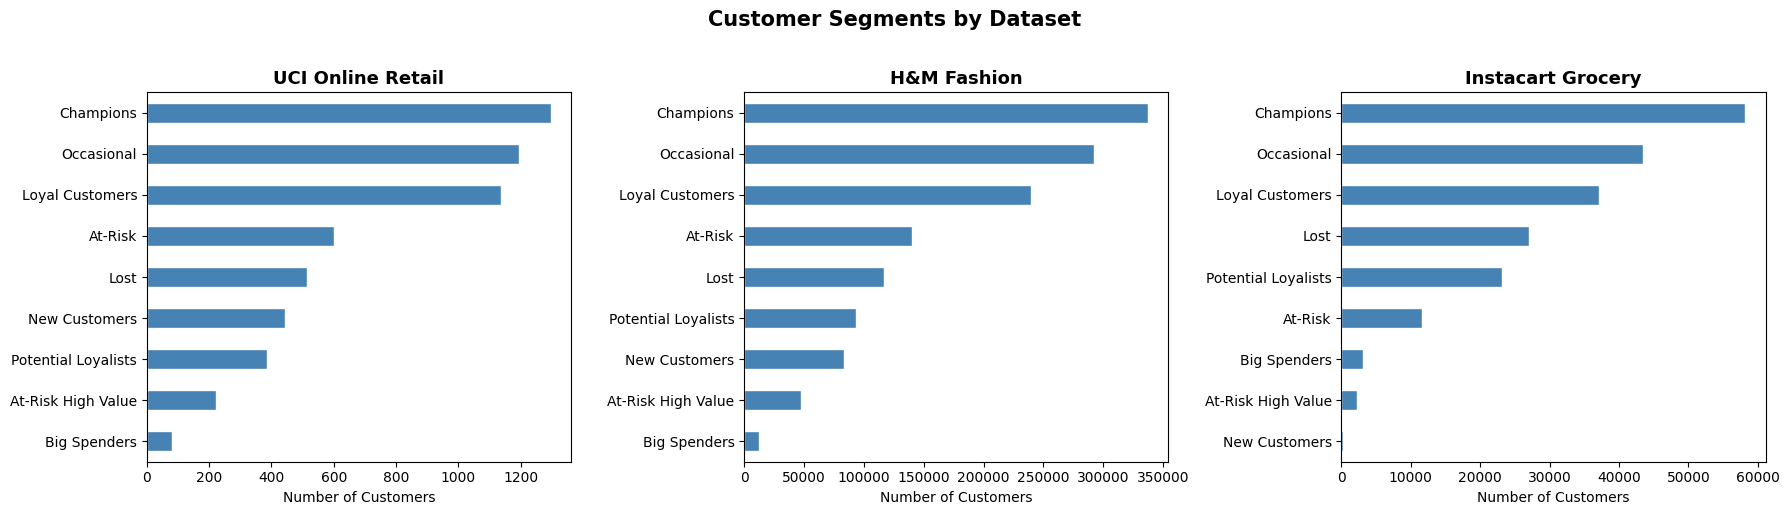

Chart saved to outputs/ ✓


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = [
    ('UCI Online Retail', rfm_uci),
    ('H&M Fashion',       rfm_hm),
    ('Instacart Grocery', rfm_inst)
]

for ax, (name, rfm) in zip(axes, datasets):
    seg_counts = rfm['segment'].value_counts()
    seg_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Customers')
    ax.set_ylabel('')
    ax.invert_yaxis()

plt.suptitle('Customer Segments by Dataset', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'outputs', 'segment_overview.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to outputs/ ✓")

In [9]:
rfm_uci.to_parquet(os.path.join(PROCESSED,  'rfm_uci.parquet'),  index=False)
rfm_hm.to_parquet(os.path.join(PROCESSED,   'rfm_hm.parquet'),   index=False)
rfm_inst.to_parquet(os.path.join(PROCESSED, 'rfm_inst.parquet'), index=False)

print("RFM tables saved ✓")
for name, rfm in [('UCI', rfm_uci), ('H&M', rfm_hm), ('Instacart', rfm_inst)]:
    print(f"  {name:12} — {len(rfm):>10,} customers | "
          f"segments: {rfm['segment'].nunique()}")

RFM tables saved ✓
  UCI          —      5,878 customers | segments: 9
  H&M          —  1,362,281 customers | segments: 9
  Instacart    —    206,209 customers | segments: 9
